<a href="https://colab.research.google.com/github/Aslil/adaMidtermProject/blob/main/AdaMidtermProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -U fastai gradio

from fastai.vision.all import *
import pandas as pd
from pathlib import Path


In [4]:
#Download the data
from google.colab import files
uploaded = files.upload()



Saving archive.zip to archive.zip


In [5]:
import zipfile

with zipfile.ZipFile("archive.zip", 'r') as zip_ref:
    zip_ref.extractall("pixel_art_data")


In [6]:
#Inspect the data layout
#Decide how to create the datablock

from pathlib import Path
import pandas as pd

#Read CSV
df = pd.read_csv("pixel_art_data/labels.csv")

#Fix Label column
def fix_label_format(x):
    x = x.replace(" ", ",")
    return eval(x)

df['Label'] = df['Label'].apply(fix_label_format)
df['category'] = df['Label'].apply(lambda x: x.index(1.0)).astype(str)

#Create new filepath
df['Image Path'] = df['Image Path'].apply(lambda x: x.replace(".jpg", ".JPEG"))  # varsa düzelt
df['filepath'] = df['Image Path'].apply(lambda x: Path("pixel_art_data/images/images") / Path(x).name)

# filter
df = df[df['filepath'].apply(lambda x: x.exists())].reset_index(drop=True)

# control
print("Satır sayısı:", df.shape[0])
df[['filepath', 'category']].head()

Satır sayısı: 89399


,filepath,category
0,pixel_art_data/images/images/image_1.JPEG,0
1,pixel_art_data/images/images/image_2.JPEG,4
2,pixel_art_data/images/images/image_3.JPEG,0
3,pixel_art_data/images/images/image_4.JPEG,4
4,pixel_art_data/images/images/image_5.JPEG,0


In [7]:
#Create the DataBlock and dataloaders

dblock = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_x=ColReader('filepath'),
    get_y=ColReader('category'),
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    item_tfms=Resize(224)
)


In [8]:
dls = dblock.dataloaders(df, bs=64)


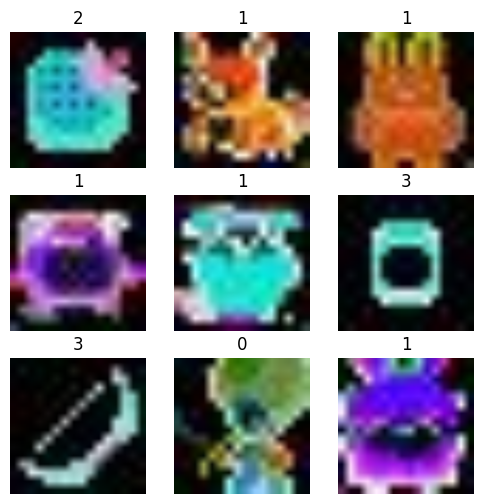

In [9]:
dls.show_batch(max_n=9, figsize=(6, 6))


In [10]:
df['category'].value_counts().sort_index()


,count
category,
0,8000
1,32400
2,6000
3,34999
4,8000


In [11]:
#Train a simple model
learn = vision_learner(dls, resnet18, metrics=accuracy)
learn.fine_tune(3)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 129MB/s]


epoch,train_loss,valid_loss,accuracy,time
0,0.020929,0.006222,0.998378,03:43


epoch,train_loss,valid_loss,accuracy,time
0,0.013074,0.005497,0.998434,04:23
1,0.003310,0.002293,0.998434,04:26
2,0.002251,0.002480,0.998434,04:27


In [12]:
learn.export("pixel_art_model.pkl")


preds shape: torch.Size([17879, 5]), targs shape: torch.Size([17879])


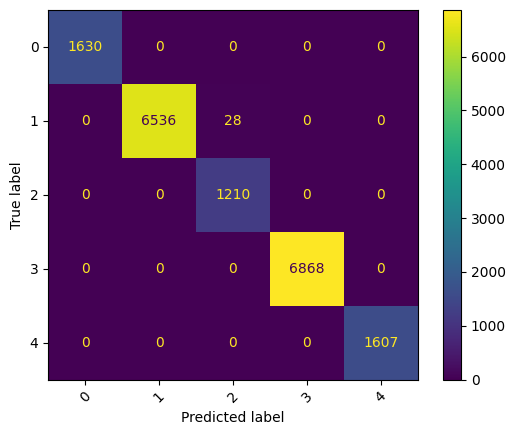

In [30]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get predictions
preds, targs = learn.get_preds(dl=dls.valid)

# Write to the screen to debug
print(f"preds shape: {preds.shape}, targs shape: {targs.shape}")

# Get class indices
pred_labels = preds.argmax(dim=1)

# Create confusion Matrix
cm = confusion_matrix(targs, pred_labels)

# Visualize
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=learn.dls.vocab)
disp.plot(xticks_rotation=45)


In [33]:
print(len(dls.train))



1117


SuggestedLRs(valley=0.0010000000474974513)

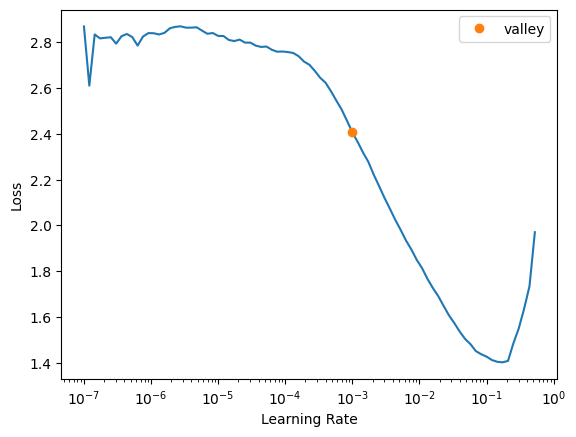

In [38]:
# Recreate learner
learn = vision_learner(dls, resnet18, metrics=accuracy)

# Run lr_find with fixed iterations
learn.lr_find(num_it=100)


In [39]:
#Transfer Learning: Freeze & Unfreeze
#Freeze only the final layer and train
learn.fine_tune(3, base_lr=1e-3)

epoch,train_loss,valid_loss,accuracy,time
0,0.020039,0.006275,0.998770,04:07


epoch,train_loss,valid_loss,accuracy,time
0,0.005982,0.006180,0.998714,04:26
1,0.002921,0.005437,0.998714,04:24
2,0.003507,0.002043,0.998378,04:25


In [45]:
# Unfreeze all layers
learn.unfreeze()

#Train with discriminative learning rate for 5 epochs
learn.fit_one_cycle(5, lr_max=slice(1e-5, 1e-3))


epoch,train_loss,valid_loss,accuracy,time
0,0.006748,0.004000,0.998770,04:39
1,0.002741,0.004721,0.998770,04:27
2,0.003218,0.002267,0.998434,04:27
3,0.002578,0.002200,0.998714,04:28
4,0.002137,0.001979,0.998714,04:28


In [48]:
#Model Capacity
#Recreate the learner with mixed precision training to reduce memory usage and increase speed
learn = vision_learner(dls, resnet18, metrics=accuracy).to_fp16()
learn.unfreeze()
learn.fit_one_cycle(5, lr_max=slice(1e-5, 1e-3))


In [49]:
learn.export("pixel_art_model.pkl")


In [50]:
import gradio as gr
from fastai.vision.all import *

# Load model
learn = load_learner("pixel_art_model.pkl")

label_names = {
    "0": "Enemies",
    "1": "Character",
    "2": "Icon",
    "3": "Item",
    "4": "Environment"
}

# Visual classification function
def classify_image(img):
    pred, idx, probs = learn.predict(img)
    return {
        label_names.get(str(learn.dls.vocab[i]), str(learn.dls.vocab[i])): float(probs[i])
        for i in range(len(probs))
    }

# interface
interface = gr.Interface(
    fn=classify_image,
    inputs=gr.Image(type="pil"),
    outputs=gr.Label(num_top_classes=3),
    title="Pixel Art Classifier",
    description="Guess which class your uploaded image belongs to. (Characters, Items, Environment, Icons, Enemies)"
)

interface.launch()

/usr/local/lib/python3.11/dist-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


It looks like you are running Gradio on a hosted a Jupyter notebook. For the Gradio app to work, sharing must be enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://729e59d895de1a3658.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
